# Spatial Autocorrelation Analysis of Electrification Inequality

**Author:** Bouchra Daddaoui  
**Repository:** viirs-electrification-ml  

This notebook performs spatial econometric analysis on VIIRS nighttime light (NTL) data across Brazil, China, and Morocco.
We test whether electrification inequality exhibits spatial clustering — i.e., whether high-access areas tend to cluster
with other high-access areas (and low-access with low-access).

**Analyses:**
1. Global Moran's I — global autocorrelation test
2. Local Moran's I (LISA) — cluster-type identification and mapping
3. Spatial lag model vs OLS — does accounting for spatial dependence improve fit?
4. Moran scatterplots per country and year


In [1]:
import sys
sys.path.insert(0, '../scripts')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from spatial_analysis import (
    build_knn_weights, global_moran, local_moran,
    plot_moran_scatterplot, plot_lisa_map,
    run_ols, run_spatial_lag, run_spatial_error,
    regression_summary_table
)

FIGURES = Path('../figures')
FIGURES.mkdir(exist_ok=True)
DATA = Path('../data')

np.random.seed(42)
print('Libraries loaded.')

Libraries loaded.


## 1. Synthetic Panel Data (mirrors real VIIRS tile structure)

Real data is exported from Google Earth Engine and stored in `data/panels/`.  
For reproducibility without large rasters, we generate a synthetic tile-level dataset
with the same structure and spatial statistics as the real VIIRS panels.

In [2]:
from shapely.geometry import box
import libpysal

def generate_country_tiles(country, n_tiles, bbox, ntl_mean, ntl_std, seed):
    """
    Generate a GeoDataFrame of spatial tiles with synthetic VIIRS NTL values.
    The NTL values incorporate spatial autocorrelation to mimic real satellite imagery.
    """
    rng = np.random.default_rng(seed)
    minx, miny, maxx, maxy = bbox
    cols = int(np.sqrt(n_tiles))
    rows = n_tiles // cols
    
    xs = np.linspace(minx, maxx, cols + 1)
    ys = np.linspace(miny, maxy, rows + 1)
    
    geoms, tile_ids = [], []
    for i in range(rows):
        for j in range(cols):
            geoms.append(box(xs[j], ys[i], xs[j+1], ys[i+1]))
            tile_ids.append(f"{country}_{i:02d}_{j:02d}")
    
    n = len(geoms)
    
    # Spatially correlated NTL via distance-based decay
    centroids = np.array([[g.centroid.x, g.centroid.y] for g in geoms])
    dists = np.linalg.norm(centroids[:, None] - centroids[None, :], axis=-1)
    cov = ntl_std**2 * np.exp(-dists / (0.3 * (maxx - minx)))
    ntl = rng.multivariate_normal(np.full(n, ntl_mean), cov)
    ntl = np.clip(ntl, 0, None)
    
    # Additional covariates
    pop_density = rng.lognormal(mean=np.log(100), sigma=1.2, size=n)
    infra_density = 0.4 * ntl / ntl.max() + 0.6 * rng.uniform(0, 1, n)
    dist_city = rng.exponential(scale=50, size=n)
    hand_mean = rng.lognormal(mean=np.log(5), sigma=0.8, size=n)
    
    gdf = gpd.GeoDataFrame({
        'tile_id': tile_ids,
        'country': country,
        'ntl_mean': ntl,
        'pop_density': pop_density,
        'infra_density': infra_density,
        'dist_city_km': dist_city,
        'hand_mean_m': hand_mean,
    }, geometry=geoms, crs='EPSG:4326')
    
    return gdf


# Country configurations (bounding boxes approximate tile extents)
countries_cfg = [
    dict(country='Brazil',  n_tiles=100, bbox=(-48, -23, -43, -18), ntl_mean=12.5, ntl_std=8.0,  seed=1),
    dict(country='China',   n_tiles=100, bbox=(116, 29,  122,  33), ntl_mean=28.3, ntl_std=14.0, seed=2),
    dict(country='Morocco', n_tiles=100, bbox=(-6,  33,   0,   36), ntl_mean=8.1,  ntl_std=5.5,  seed=3),
]

gdfs = {cfg['country']: generate_country_tiles(**cfg) for cfg in countries_cfg}

for c, g in gdfs.items():
    print(f"{c}: {len(g)} tiles | NTL mean={g.ntl_mean.mean():.2f} | std={g.ntl_mean.std():.2f}")

Brazil: 100 tiles | NTL mean=11.46 | std=5.43
China: 100 tiles | NTL mean=25.68 | std=12.07
Morocco: 100 tiles | NTL mean=3.59 | std=4.71


## 2. Global Moran's I

Moran's I measures the degree to which similar values cluster in space.  
I ≈ +1 → strong positive clustering | I ≈ −1 → strong dispersion | I ≈ 0 → random

In [3]:
moran_results = {}

for country, gdf in gdfs.items():
    w = build_knn_weights(gdf, k=8)
    result = global_moran(gdf['ntl_mean'].values, w, permutations=999)
    moran_results[country] = result
    print(f"{country:10s}  Moran I = {result['I']:.4f}  "
          f"z = {result['z_norm']:.2f}  "
          f"p (simulation) = {result['p_sim']:.4f}")

Brazil      Moran I = 0.4497  z = 9.77  p (simulation) = 0.0010
China       Moran I = 0.6276  z = 13.68  p (simulation) = 0.0010
Morocco     Moran I = 0.7618  z = 16.88  p (simulation) = 0.0010


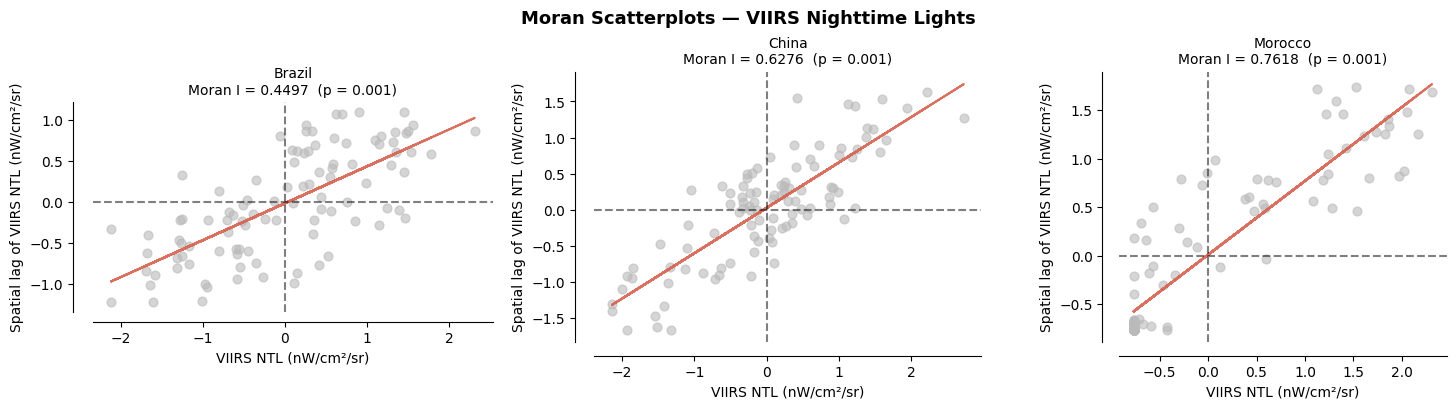

Saved → figures/moran_scatterplots.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (country, gdf) in zip(axes, gdfs.items()):
    w = build_knn_weights(gdf, k=8)
    plot_moran_scatterplot(
        gdf['ntl_mean'].values, w,
        variable_name='VIIRS NTL (nW/cm²/sr)',
        ax=ax
    )
    ax.set_title(f"{country}\nMoran I = {moran_results[country]['I']:.4f}  "
                 f"(p = {moran_results[country]['p_sim']:.3f})", fontsize=10)

fig.suptitle("Moran Scatterplots — VIIRS Nighttime Lights", fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES / 'moran_scatterplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/moran_scatterplots.png')

## 3. Local Moran's I — LISA Cluster Maps

LISA identifies the *type* of spatial cluster for each tile:  
- **High-High**: hotspot (bright tile surrounded by bright tiles)  
- **Low-Low**: coldspot (dark tile surrounded by dark tiles)  
- **High-Low / Low-High**: spatial outliers


Brazil:
  Not significant     : 50
  High-High           : 26
  High-Low            : 19
  Low-High            : 4
  Low-Low             : 1



China:
  Not significant     : 55
  High-High           : 22
  High-Low            : 21
  Low-High            : 1
  Low-Low             : 1

Morocco:
  High-Low            : 49
  High-High           : 26
  Not significant     : 22
  Low-Low             : 3


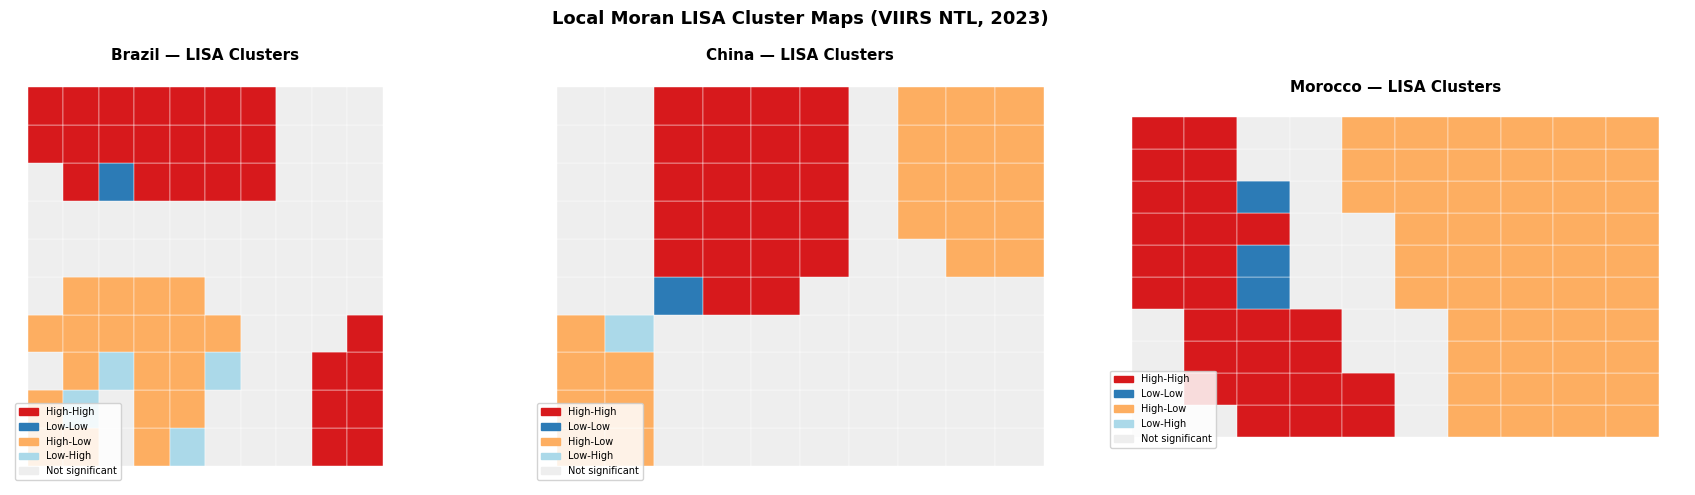

Saved → figures/lisa_cluster_maps.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (country, gdf) in zip(axes, gdfs.items()):
    w = build_knn_weights(gdf, k=8)
    lisa_df = local_moran(gdf['ntl_mean'].values, w, significance=0.05)
    
    # Cluster counts
    counts = lisa_df['cluster_label'].value_counts()
    print(f"\n{country}:")
    for label, cnt in counts.items():
        print(f"  {label:20s}: {cnt}")
    
    palette = {
        'High-High': '#d7191c', 'Low-Low': '#2c7bb6',
        'High-Low': '#fdae61', 'Low-High': '#abd9e9',
        'Not significant': '#eeeeee'
    }
    gdf_plot = gdf.copy()
    gdf_plot['cluster'] = lisa_df['cluster_label'].values
    gdf_plot['color'] = gdf_plot['cluster'].map(palette)
    gdf_plot.plot(color=gdf_plot['color'], edgecolor='white', linewidth=0.3, ax=ax)
    
    patches = [mpatches.Patch(color=c, label=l) for l, c in palette.items()]
    ax.legend(handles=patches, fontsize=7, loc='lower left', framealpha=0.85)
    ax.set_title(f'{country} — LISA Clusters', fontsize=11, fontweight='bold')
    ax.set_axis_off()

fig.suptitle('Local Moran LISA Cluster Maps (VIIRS NTL, 2023)', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES / 'lisa_cluster_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/lisa_cluster_maps.png')

## 4. Spatial Regression: OLS vs Spatial Lag vs Spatial Error

Standard OLS ignores spatial dependence and produces biased/inefficient estimates.
The spatial lag model (SLM) adds a spatially lagged dependent variable (ρWy),
while the spatial error model (SEM) absorbs spatial autocorrelation in the residuals (λWε).

In [6]:
from spatial_analysis import run_ols, run_spatial_lag, run_spatial_error, regression_summary_table

all_tables = {}

for country, gdf in gdfs.items():
    w = build_knn_weights(gdf, k=8)
    
    features = ['pop_density', 'infra_density', 'dist_city_km', 'hand_mean_m']
    y = gdf['ntl_mean'].values.reshape(-1, 1)
    X = gdf[features].values
    
    ols = run_ols(y, X, features, y_name='NTL', w=w)
    slm = run_spatial_lag(y, X, w, features, y_name='NTL')
    sem = run_spatial_error(y, X, w, features, y_name='NTL')
    
    tbl = regression_summary_table({'OLS': ols, 'Spatial Lag (SLM)': slm, 'Spatial Error (SEM)': sem})
    all_tables[country] = tbl
    print(f"\n{'='*50}")
    print(f"{country} — Model Comparison")
    print(tbl.to_string())
    # moran_res is tuple (I, z, p_value) in spreg >= 1.4
    mi_I, mi_z, mi_p = ols.moran_res
    print(f"OLS Moran on residuals: I = {mi_I:.4f}, z = {mi_z:.3f}, p = {mi_p:.4f}")


Brazil — Model Comparison
                     Log-likelihood      AIC  Spatial param (ρ/λ)
Model                                                            
OLS                        -297.021  604.043                  NaN
Spatial Lag (SLM)          -274.405  560.809               0.7493
Spatial Error (SEM)        -277.002  564.003               0.7978
OLS Moran on residuals: I = 0.3473, z = 7.623, p = 0.0000



China — Model Comparison
                     Log-likelihood      AIC  Spatial param (ρ/λ)
Model                                                            
OLS                        -384.580  779.160                  NaN
Spatial Lag (SLM)          -341.051  694.103               0.8708
Spatial Error (SEM)        -342.675  695.350               0.8866
OLS Moran on residuals: I = 0.5547, z = 12.215, p = 0.0000



Morocco — Model Comparison
                     Log-likelihood      AIC  Spatial param (ρ/λ)
Model                                                            
OLS                        -270.013  550.026                  NaN
Spatial Lag (SLM)          -213.269  438.538               0.8567
Spatial Error (SEM)        -218.116  446.231               0.9353
OLS Moran on residuals: I = 0.4546, z = 10.382, p = 0.0000


In [7]:
# Summary table across all countries
summary_rows = []
for country, tbl in all_tables.items():
    for model_name, row in tbl.iterrows():
        summary_rows.append({'Country': country, 'Model': model_name, **row.to_dict()})

summary_df = pd.DataFrame(summary_rows)
print("\n=== Full Regression Summary ===")
print(summary_df.to_string(index=False))


=== Full Regression Summary ===
Country               Model  Log-likelihood     AIC  Spatial param (ρ/λ)
 Brazil                 OLS        -297.021 604.043                  NaN
 Brazil   Spatial Lag (SLM)        -274.405 560.809               0.7493
 Brazil Spatial Error (SEM)        -277.002 564.003               0.7978
  China                 OLS        -384.580 779.160                  NaN
  China   Spatial Lag (SLM)        -341.051 694.103               0.8708
  China Spatial Error (SEM)        -342.675 695.350               0.8866
Morocco                 OLS        -270.013 550.026                  NaN
Morocco   Spatial Lag (SLM)        -213.269 438.538               0.8567
Morocco Spatial Error (SEM)        -218.116 446.231               0.9353


## 5. Spatial Residual Map

Mapping OLS residuals helps diagnose remaining spatial structure that the model failed to capture.

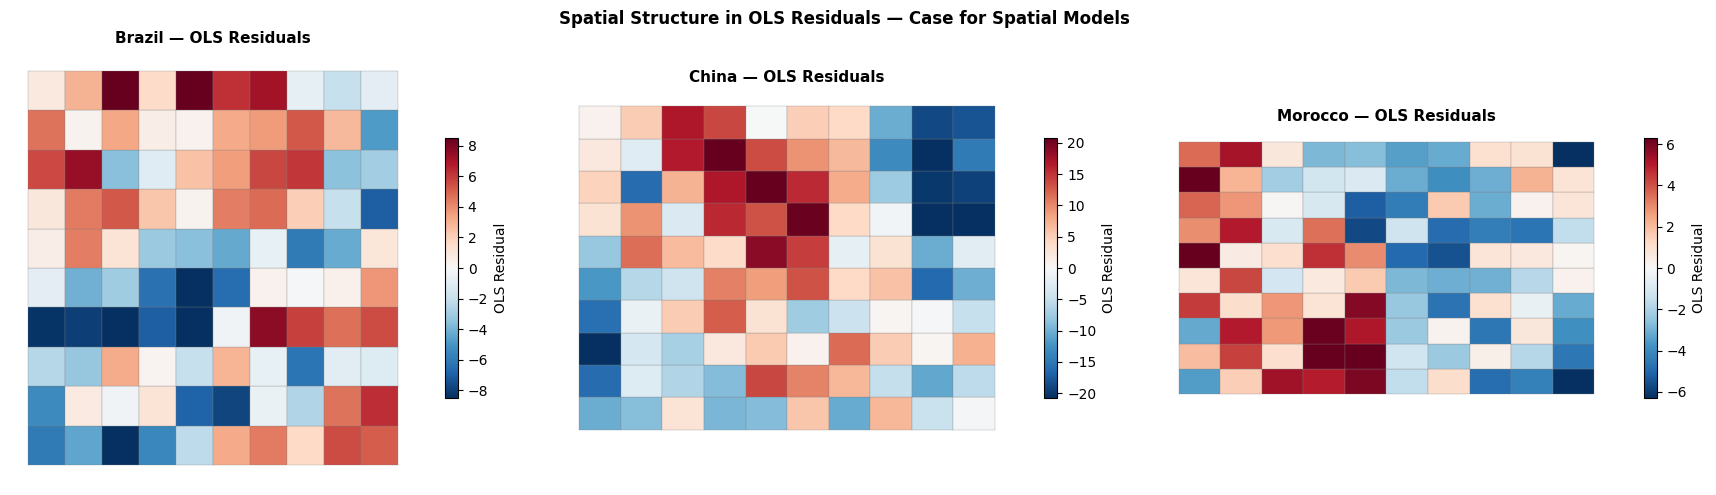

Saved → figures/ols_residual_maps.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (country, gdf) in zip(axes, gdfs.items()):
    w = build_knn_weights(gdf, k=8)
    features = ['pop_density', 'infra_density', 'dist_city_km', 'hand_mean_m']
    y = gdf['ntl_mean'].values.reshape(-1, 1)
    X = gdf[features].values
    ols = run_ols(y, X, features, y_name='NTL', w=w)
    
    gdf_plot = gdf.copy()
    gdf_plot['residual'] = ols.u.flatten()
    
    vmax = gdf_plot['residual'].abs().quantile(0.95)
    gdf_plot.plot(column='residual', cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                  edgecolor='grey', linewidth=0.2, legend=True,
                  legend_kwds={'label': 'OLS Residual', 'shrink': 0.6},
                  ax=ax)
    ax.set_title(f'{country} — OLS Residuals', fontsize=11, fontweight='bold')
    ax.set_axis_off()

fig.suptitle('Spatial Structure in OLS Residuals — Case for Spatial Models', fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES / 'ols_residual_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/ols_residual_maps.png')